# Numerical Columns

## Setting a Ground Truth

In order to determine which imputation method performs best, we apply a Missing Completely At Random (MCAR) mechanism to the cleaned DataFrame and compare the imputed values with the original observed values using evaluation metrics.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from taxipred.utils.constants import TAXI_CSV_PATH

df = pd.read_csv(TAXI_CSV_PATH)
df.info()

# the original DF where we have 5% null values per column,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [21]:
df_clean = df.dropna().copy()
df_clean.info()

# this will be our ground truth and we will applying 5% MCAR for each column just like we have observed in our original DF.

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Time_of_Day            562 non-null    object 
 2   Day_of_Week            562 non-null    object 
 3   Passenger_Count        562 non-null    float64
 4   Traffic_Conditions     562 non-null    object 
 5   Weather                562 non-null    object 
 6   Base_Fare              562 non-null    float64
 7   Per_Km_Rate            562 non-null    float64
 8   Per_Minute_Rate        562 non-null    float64
 9   Trip_Duration_Minutes  562 non-null    float64
 10  Trip_Price             562 non-null    float64
dtypes: float64(7), object(4)
memory usage: 52.7+ KB


In [22]:
# Extract column types (will be reused for categorical section)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

# getting rid of the non-numeric columns for numerical imputation
df_clean_num = df_clean[numeric_cols].copy()
df_clean_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


In [23]:
# applying MCAR mechanism at 5% 

np.random.seed(42)  # Set random seed for reproducibility
mask_matrix = pd.DataFrame(
    np.random.rand(*df_clean_num.shape) < 0.05,
    index=df_clean_num.index,
    columns=df_clean_num.columns
)

df_masked_num = df_clean_num.mask(mask_matrix)

df_masked_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       534 non-null    float64
 1   Passenger_Count        531 non-null    float64
 2   Base_Fare              531 non-null    float64
 3   Per_Km_Rate            530 non-null    float64
 4   Per_Minute_Rate        535 non-null    float64
 5   Trip_Duration_Minutes  536 non-null    float64
 6   Trip_Price             538 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


## Imputation

I will be applying different imputation methods on the "Ground Truth" dataset and compare evaluation performances to decide which one fits better to fill the null values on the original data.

## Helper Functions

In [24]:
def apply_imputation(imputer, df_masked, show_info=True):
    """
    Helper function to apply imputation and return DataFrame with preserved index/columns.
    
    Parameters:
    -----------
    imputer : sklearn imputer object
        Fitted or to-be-fitted imputer
    df_masked : pd.DataFrame
        DataFrame with missing values
    show_info : bool
        Whether to display .info() output
        
    Returns:
    --------
    pd.DataFrame : Imputed DataFrame with same index and columns
    """
    df_imputed = pd.DataFrame(
        imputer.fit_transform(df_masked),
        columns=df_masked.columns,
        index=df_masked.index
    )
    if show_info:
        df_imputed.info()
    return df_imputed

### Mean Imputation
- This method involves replacing missing values with the mean of the relevant variable. It's a simple approach but it doesn't account for the relationships between variables.

In [25]:
mean_imputer = SimpleImputer(strategy="mean")
df_mean = apply_imputation(mean_imputer, df_masked_num)

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


### Linear Imputation

- Pros: captures trends, preserves relationships
- Cons: assumes a pattern (linear) may be complex

In [26]:
linear_imputer = IterativeImputer(
    estimator=LinearRegression(),
    max_iter=1,               # key: one pass (linear regression baseline)
    random_state=42,
    sample_posterior=False
)

df_linear = apply_imputation(linear_imputer, df_masked_num)


<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


/home/apollonspc/taxi-prediction-fullstack-omer-aytug/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### MICE Imputation
- MICE (Multiple Imputation by Chained Equations) style chained equations (iterative regression imputation) to preserve relationships between variables.

In [27]:
mice_imputer = IterativeImputer(
    estimator=LinearRegression(),
    random_state=42,
    max_iter=20,
    sample_posterior=False
)

df_mice = apply_imputation(mice_imputer, df_masked_num)

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


## Evaluation
- RMSE/MAE only on masked cells

In [28]:
# Only evaluate at positions we intentionally masked
y_true = df_clean_num.values[mask_matrix.values]
imputed_results = {
    "Mean": df_mean.values[mask_matrix.values],
    "LinearRegression": df_linear.values[mask_matrix.values],
    "MICE": df_mice.values[mask_matrix.values]
}

def rmse(y_t, y_p):
    return np.sqrt(mean_squared_error(y_t, y_p))

def mae(y_t, y_p):
    return mean_absolute_error(y_t, y_p)

results = pd.DataFrame({
    "RMSE": [rmse(y_true, y_pred) for y_pred in imputed_results.values()],
    "MAE":  [mae(y_true, y_pred) for y_pred in imputed_results.values()]
}, index=imputed_results.keys())

display(results.sort_values("RMSE"))



,RMSE,MAE
MICE,12.149744,5.357452
LinearRegression,12.205319,5.476082
Mean,24.742545,9.990014


- Structure check (varience comparison)

In [29]:
var_compare = pd.DataFrame({
    "True (df_clean_num)": df_clean_num.var(),
    "Mean Imputed": df_mean.var(),
    "Linear Imputed": df_linear.var(),
    "MICE": df_mice.var()
})

display(var_compare)


,True (df_clean_num),Mean Imputed,Linear Imputed,MICE
Trip_Distance_km,447.456825,424.390713,461.608266,461.466639
Passenger_Count,1.229693,1.156114,1.157484,1.157520
Base_Fare,0.758784,0.718160,0.718720,0.718712
Per_Km_Rate,0.185202,0.177757,0.179720,0.179787
Per_Minute_Rate,0.013187,0.012535,0.012557,0.012588
Trip_Duration_Minutes,1032.236406,991.889155,997.169341,1004.625668
Trip_Price,1932.370937,1778.883223,1881.923037,1886.645777


### Plot Evaluation

- Analyzing the performance of our imputation models by comparing imputed valued with the actual values for some of the columns

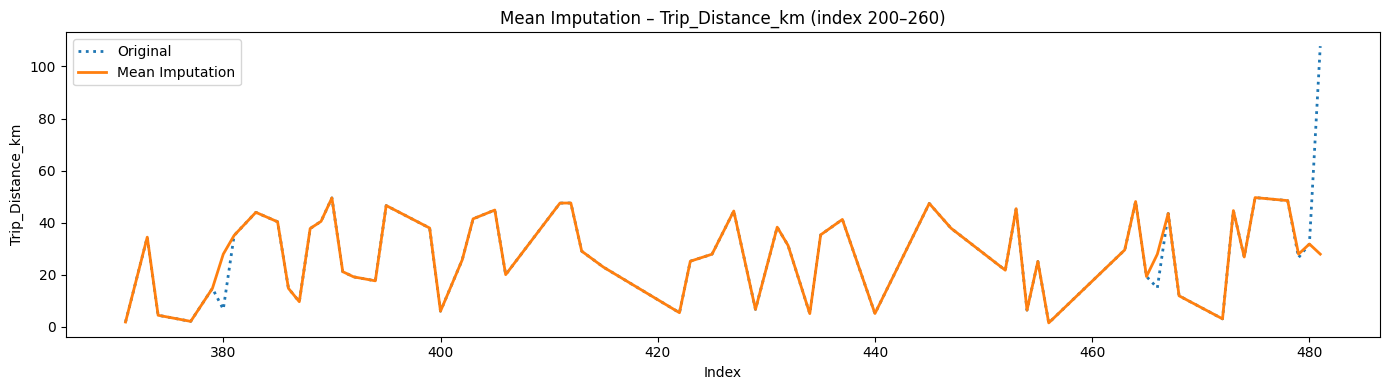

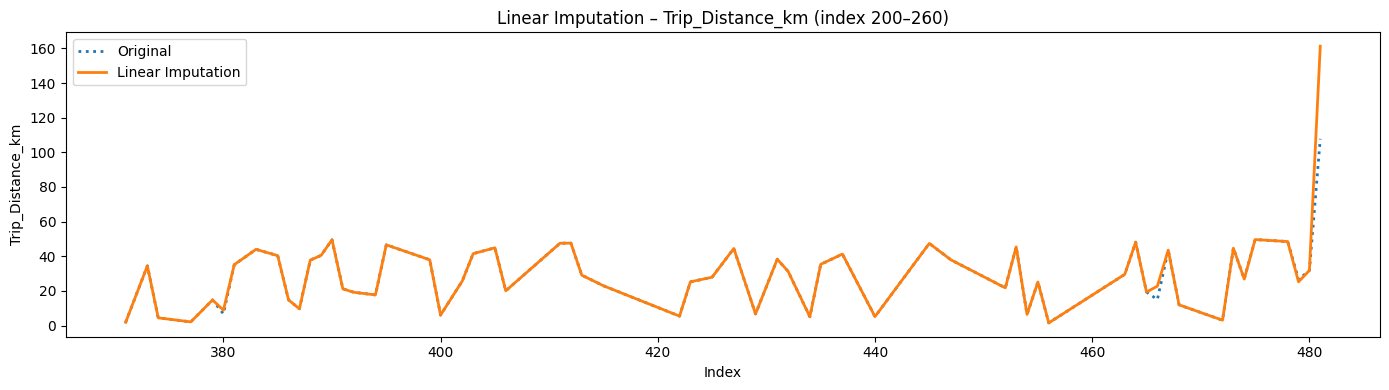

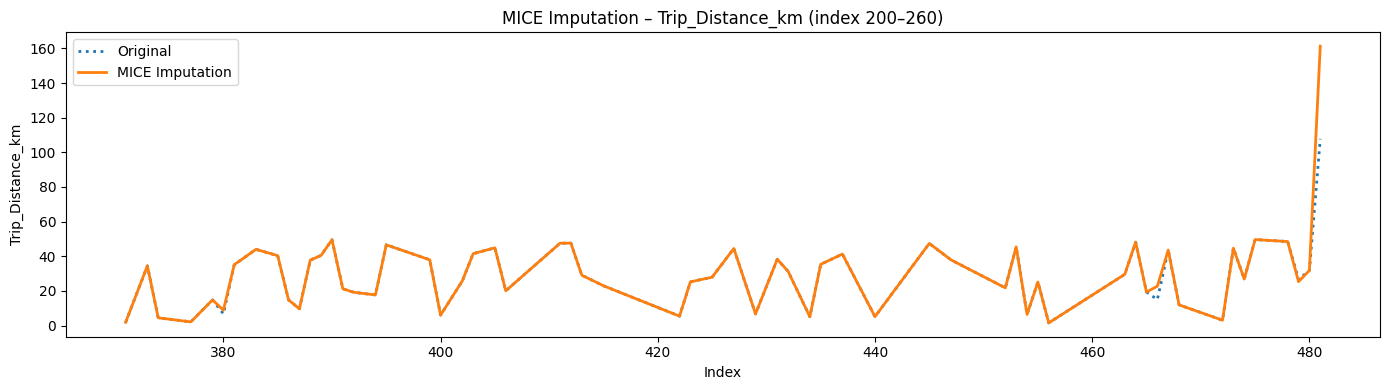

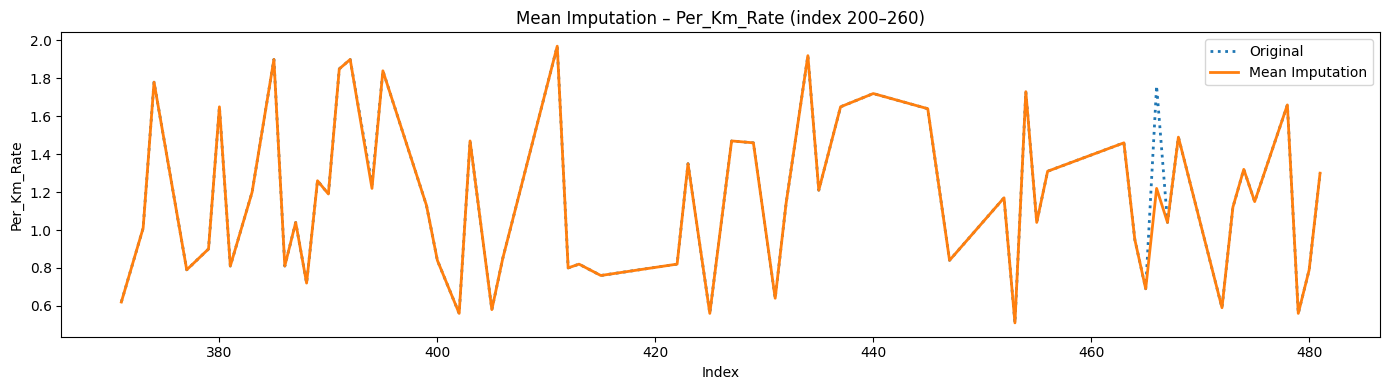

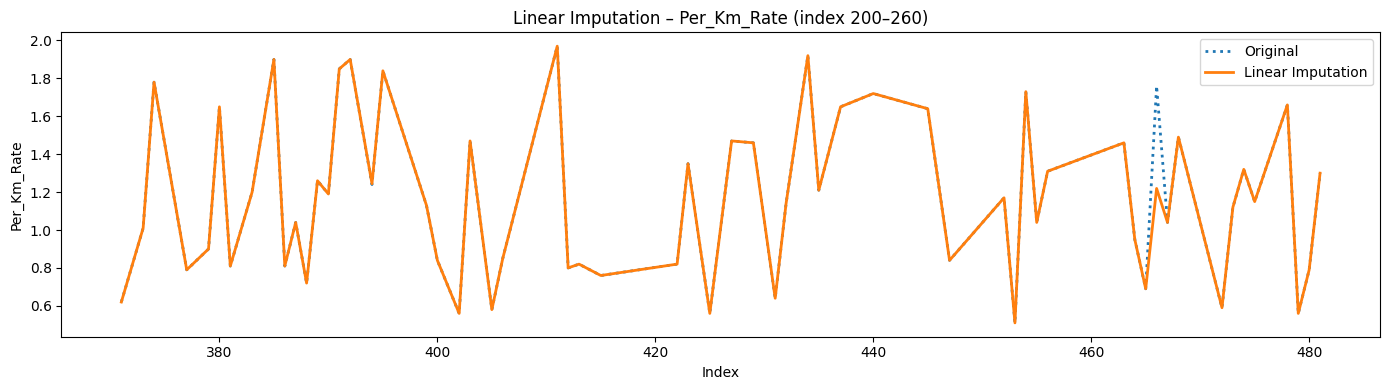

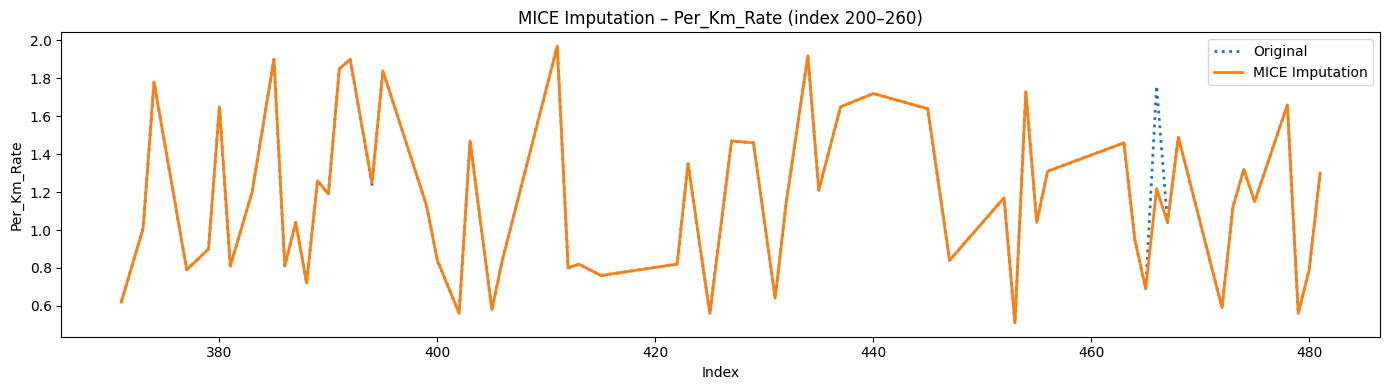

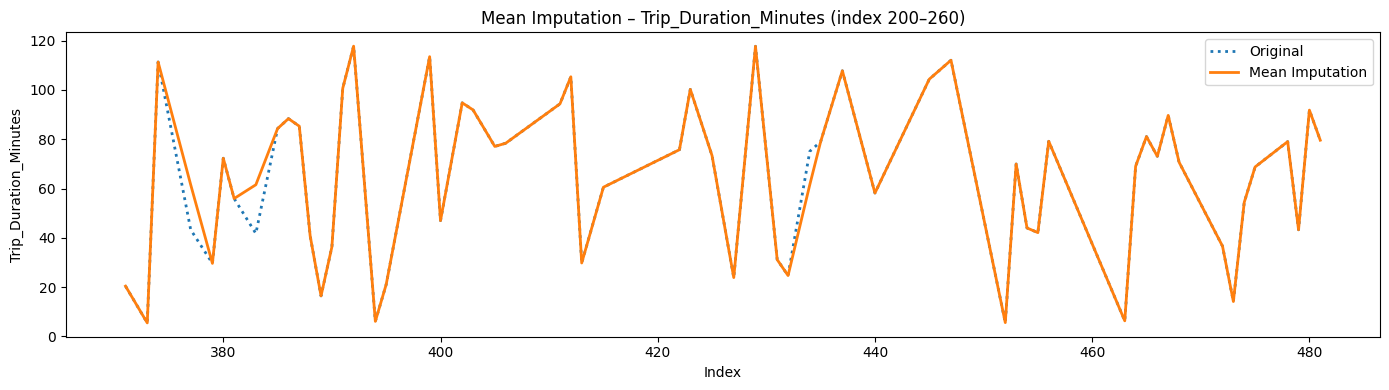

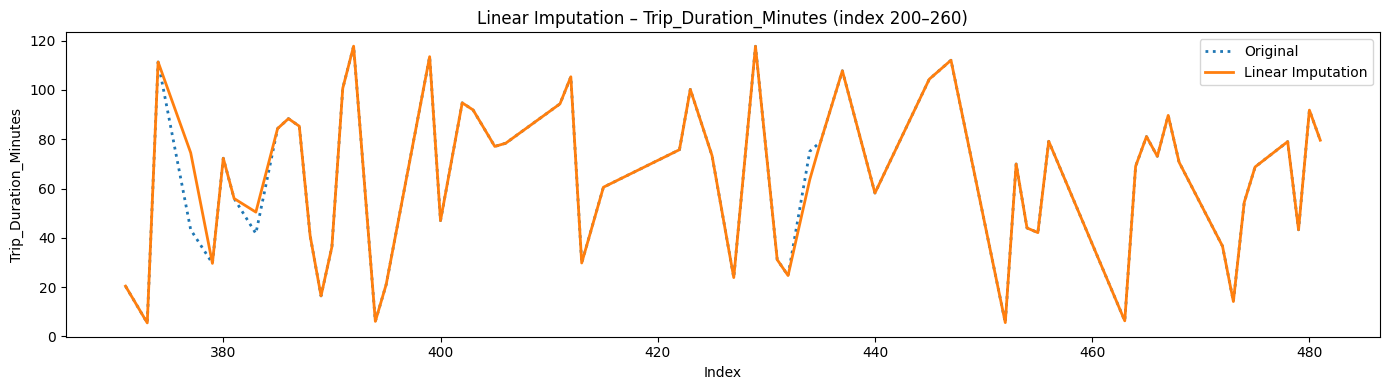

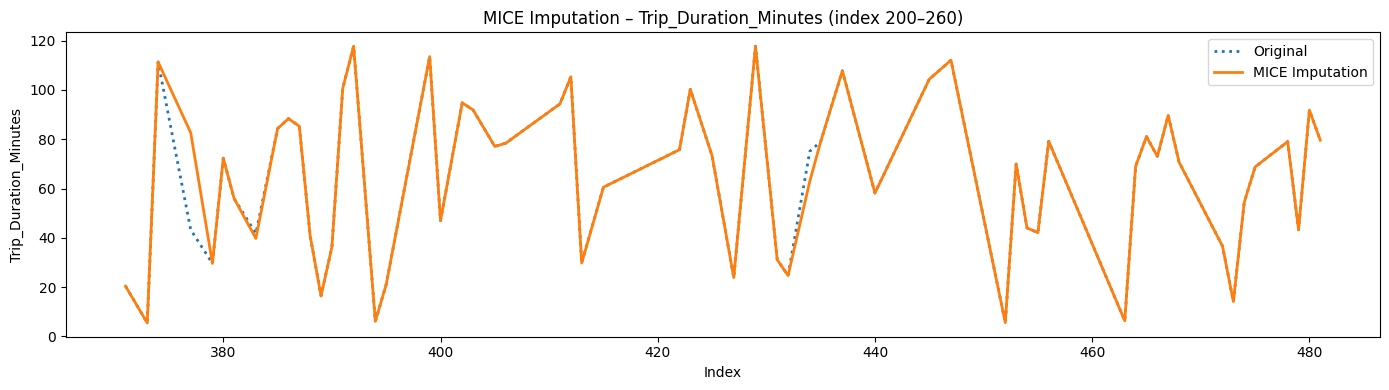

In [30]:
import matplotlib.pyplot as plt

cols_to_check = [
    "Trip_Distance_km",
    "Per_Km_Rate",
    "Trip_Duration_Minutes"
]

start, end = 200, 260   # zoom window

methods = {
    "Mean Imputation": df_mean,
    "Linear Imputation": df_linear,
    "MICE Imputation": df_mice
}

for col in cols_to_check:
    for method_name, df_imp in methods.items():
        plt.figure(figsize=(14, 4))

        # Original (ground truth)
        plt.plot(
            df_clean[col].iloc[start:end],
            label="Original",
            linestyle="dotted",
            linewidth=2
        )

        # Imputed version
        plt.plot(
            df_imp[col].iloc[start:end],
            label=method_name,
            linewidth=2
        )

        plt.title(f"{method_name} – {col} (index {start}–{end})")
        plt.xlabel("Index")
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.show()


- Analyzing our imputation models based on their distributation performance

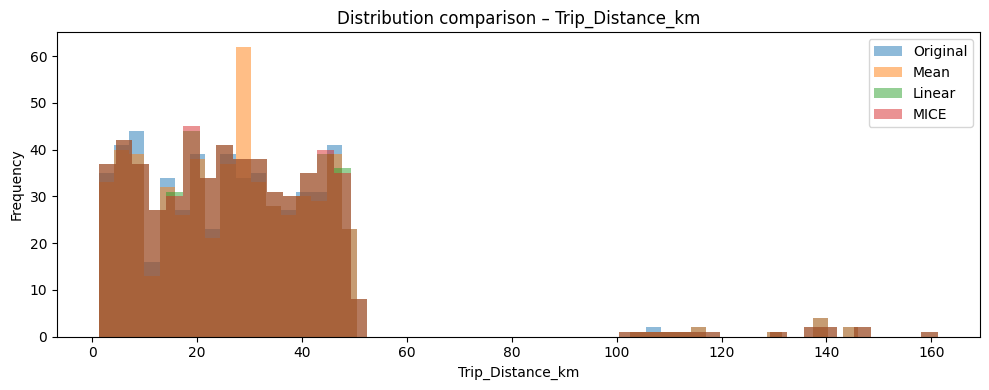

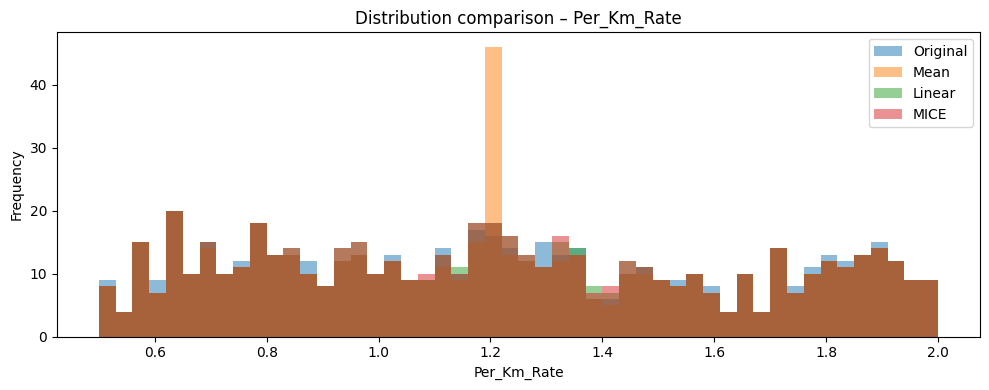

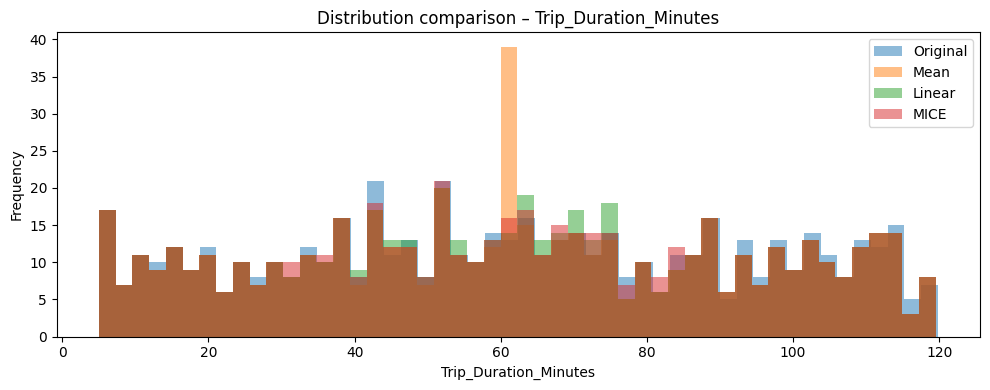

In [31]:
for col in cols_to_check:
    plt.figure(figsize=(10, 4))

    plt.hist(df_clean_num[col], bins=50, alpha=0.5, label="Original")
    plt.hist(df_mean[col], bins=50, alpha=0.5, label="Mean")
    plt.hist(df_linear[col], bins=50, alpha=0.5, label="Linear")
    plt.hist(df_mice[col], bins=50, alpha=0.5, label="MICE")

    plt.title(f"Distribution comparison – {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Categorical Columns
- Categorical variables contained missing values that could not be handled by row deletion without substantial data loss. Therefore, imputation methods will be applied to recover missing categories while preserving the underlying structure of the data.

## Setting a Ground Truth

- Just like we did for the numerical columns, we are going to get rid of our null values and apply a 5% MCAR for the clean data. 

In [32]:
# Column types already defined in cell 5 - reusing them here
# num_cols and cat_cols are already available

In [33]:
def create_mcar_mask(df, col, frac=0.05, random_state=42):
    np.random.seed(random_state)
    # Get indices where the column is not null
    valid_idx = df.index[df[col].notna()]
    # Sample a fraction of these indices
    mask_idx = pd.Index(valid_idx).to_series().sample(frac=frac, random_state=random_state).index
    return mask_idx

## Imputation

### Model Imputation
- Missing categories will be imputed using supervised classification models that predict values based on observed numerical and categorical features. This method will be used if it achieves higher macro-F1 scores.

In [34]:
def evaluate_categorical_imputation(df, cat_col, mask_idx, imputation_func, **imputation_kwargs):
    """
    Generic function to evaluate categorical imputation methods.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Ground truth DataFrame
    cat_col : str
        Categorical column to evaluate
    mask_idx : pd.Index
        Indices to mask for evaluation
    imputation_func : callable
        Function that takes (df, cat_col, ...) and returns imputed DataFrame
    **imputation_kwargs : dict
        Additional keyword arguments to pass to imputation_func
        
    Returns:
    --------
    dict : Dictionary with accuracy and f1_macro scores
    """
    df_eval = df.copy()
    true_values = df_eval.loc[mask_idx, cat_col]
    df_eval.loc[mask_idx, cat_col] = np.nan
    
    df_imputed = imputation_func(df_eval, cat_col, **imputation_kwargs)
    preds = df_imputed.loc[mask_idx, cat_col]
    
    return {
        "accuracy": accuracy_score(true_values, preds),
        "f1_macro": f1_score(true_values, preds, average="macro")
    }

def evaluate_model_imputation(df, cat_col, num_cols, cat_cols, mask_idx):
    """Evaluate model-based imputation for categorical column."""
    return evaluate_categorical_imputation(
        df, cat_col, mask_idx, 
        impute_categorical_column,
        num_cols=num_cols, cat_cols=cat_cols
    )


### Mode Imputation (Most-Frequent)
- Missing categories are imputed using the most-frequent value for variables with high class imbalance or when model-based imputation does not improve performance.

In [ ]:
def impute_most_frequent(df, cat_col):
    """Impute using most frequent value strategy."""
    imputer = SimpleImputer(strategy="most_frequent")
    df_imputed = df.copy()
    df_imputed[[cat_col]] = imputer.fit_transform(df_imputed[[cat_col]])
    return df_imputed

def evaluate_most_frequent_imputation(df, cat_col, mask_idx):
    """Evaluate most-frequent imputation for categorical column."""
    return evaluate_categorical_imputation(
        df, cat_col, mask_idx, 
        impute_most_frequent
    )


### Imputer

In [36]:
def impute_categorical_column(df, target_col, num_cols, cat_cols, random_state=42):
    """
    Model-based imputation for a single categorical column.
    """

    df = df.copy()

    # rows with / without missing target
    train_idx = df[target_col].notna()
    test_idx  = df[target_col].isna()

    # nothing to impute
    if test_idx.sum() == 0:
        return df

    X_train = df.loc[train_idx].drop(columns=[target_col])
    y_train = df.loc[train_idx, target_col]
    X_test  = df.loc[test_idx].drop(columns=[target_col])

    # predictors
    num_features = num_cols
    cat_features = [c for c in cat_cols if c != target_col]

    # preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_features)
        ]
    )

    # classifier
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced"
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", model)
    ])

    # fit + predict
    pipe.fit(X_train, y_train)
    df.loc[test_idx, target_col] = pipe.predict(X_test)

    return df


## Evaluation

In [37]:
for col in cat_cols:
    mask_idx = create_mcar_mask(df_clean, col)

    mode_scores  = evaluate_most_frequent_imputation(df_clean, col, mask_idx)
    model_scores = evaluate_model_imputation(df_clean, col, numeric_cols, cat_cols, mask_idx)

    print(col)
    print("  Mode :", mode_scores)
    print("  Model:", model_scores)


Time_of_Day
  Mode : {'accuracy': 0.42857142857142855, 'f1_macro': 0.15}
  Model: {'accuracy': 0.25, 'f1_macro': 0.15000000000000002}
Day_of_Week
  Mode : {'accuracy': 0.6428571428571429, 'f1_macro': 0.391304347826087}
  Model: {'accuracy': 0.5714285714285714, 'f1_macro': 0.36363636363636365}
Traffic_Conditions
  Mode : {'accuracy': 0.25, 'f1_macro': 0.13333333333333333}
  Model: {'accuracy': 0.39285714285714285, 'f1_macro': 0.29333333333333333}
Weather
  Mode : {'accuracy': 0.7142857142857143, 'f1_macro': 0.2777777777777778}
  Model: {'accuracy': 0.7142857142857143, 'f1_macro': 0.37060041407867494}
